In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import cv2
import random
from tensorflow.keras import layers, models

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

data_dir = r"C:\Users\chandu\Documents\SEMISTER-8\Soil_Types DataSet\train"

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 6467 files belonging to 6 classes.
Using 5174 files for training.
Found 6467 files belonging to 6 classes.
Using 1293 files for validation.


In [4]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['alluvial_soil', 'black_soil', 'clay_soil', 'laterite_soil', 'red_soil', 'yellow_soil']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [8]:
model = models.Sequential([
    data_augmentation,

    layers.Rescaling(1./255),   # 🔥 IMPORTANT (fixes high loss)

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [11]:
class_weight = {
    0:1.0,
    1:1.0,
    2:2.0,
    3:2.0,
    4:1.0,
    5:1.0
}

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 134s 739ms/step - accuracy: 0.2940 - loss: 2.5445 - val_accuracy: 0.6527 - val_loss: 0.9852
Epoch 2/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 113s 700ms/step - accuracy: 0.6164 - loss: 1.3218 - val_accuracy: 0.7131 - val_loss: 0.8071
Epoch 3/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 127s 783ms/step - accuracy: 0.6794 - loss: 1.0939 - val_accuracy: 0.7378 - val_loss: 0.7190
Epoch 4/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 123s 759ms/step - accuracy: 0.7353 - loss: 0.9038 - val_accuracy: 0.7633 - val_loss: 0.6714
Epoch 5/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 124s 768ms/step - accuracy: 0.7418 - loss: 0.8714 - val_accuracy: 0.7726 - val_loss: 0.6350
Epoch 6/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 129s 798ms/step - accuracy: 0.7722 - loss: 0.7792 - val_accuracy: 0.7834 - val_loss: 0.6062
Epoch 7/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 127s 782ms/step - accuracy: 0.7803 - loss: 0.7430 - val_accuracy: 0.7935 - val_loss: 0.5806
Epoch 8/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 119s 736ms/step - accuracy: 0.8173 -

In [13]:
model.evaluate(val_ds)

41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 569ms/step - accuracy: 0.8070 - loss: 0.5096


[0.48419052362442017, 0.8221191167831421]

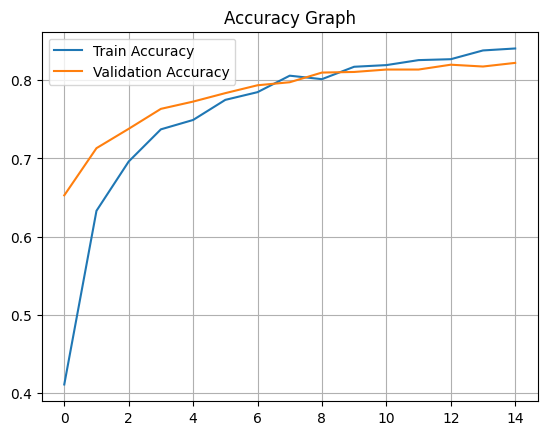

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Graph')
plt.grid()
plt.show()

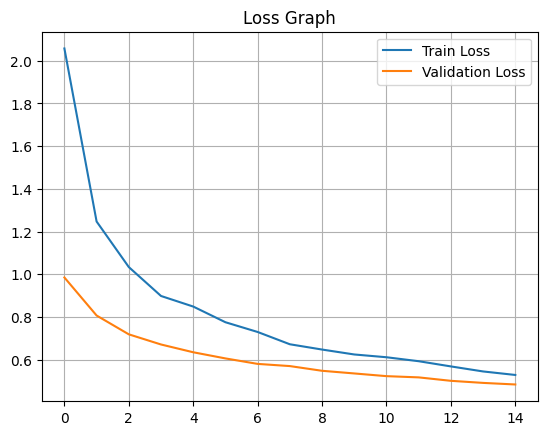

In [15]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss Graph')
plt.grid()
plt.show()

In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("42.jpeg", target_size=(224, 224))

img_array = image.img_to_array(img)   # ❗ no /255 here
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Raw prediction:", prediction)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Soil Type:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Raw prediction: [[4.1517563e-02 3.2403367e-04 6.2248390e-04 2.7415005e-03 7.1517094e-03
  9.4764280e-01]]
Predicted Soil Type: yellow_soil


In [37]:
model.save("Soil_type_CNN_Model.keras")